# Resources

[1. Problem figuring out the inputs to a fully connected layer from convolutional layer in a CNN](https://stats.stackexchange.com/questions/291935/problem-figuring-out-the-inputs-to-a-fully-connected-layer-from-convolutional-la)

[2. Determining output size for images, giving a pading, stride, input and filter size](https://stats.stackexchange.com/questions/297678/how-to-calculate-optimal-zero-padding-for-convolutional-neural-networks)

[3. Equivariance, Part 1](https://fabianfuchsml.github.io/equivariance1of2/)

[4. Equivariance, Part 2](https://fabianfuchsml.github.io/equivariance2of2/)

In [1]:
from utils.imports import *

### 2.1.c)

This toy experiment yields results that could be easily perceived as hard proof and based upon which one can make the following case: A convolutional neural network is nothing else but a far smarter and well-constrained solution derived from the same basis as the one fully connected layers draw upon. The point of difference between FCN and a 1D-convolutional layer is entirely made from a dimensional mismatch at an output level: the output layer holds 10 neurons and activation maps (2, 5). In spite of this, the content remains exactly the same.

In [2]:
# 1. Declaring the variables (e.g., upper and lower bounds of the random initialization and number of elements equivalent to the number of input neurons);
elements:int = 5
lwb, upb = 0, 10
random_vector= torch.tensor([rdm.randint(lwb,upb) for item in range(elements)], dtype=torch.float32).unsqueeze(0).unsqueeze(0)

# 2.1 Building the 1DCN and Linearity;
cnv1 = nn.Conv1d(in_channels=1, out_channels=2, padding='same', bias=True, kernel_size=3)
linear1 = nn.Linear(in_features=5, out_features=10, bias=True)

# 2.2 Weight transfer;
# 2.2.1 Zero out all the randomly initialized weights within W matrix of linear1;
linear1.weight.data.zero_()

# 3. Weight transfer loop mechanism
with torch.no_grad():
    linear1.weight.data.zero_()
    linear1.bias.data.zero_()
    all_Kernels = cnv1.weight.data
    pad:int = 1
    # 2. Loop through the 10 output rows
    for record in range(10):
        # 3. Determine which filter to use and calculate the local step 's'
        if record >= 5:
            current_kernel = all_Kernels[1, 0] # Grab filter 1
            s = record - 5                     # s resets to 0-4 for the second half
            linear1.bias.data[record:] = cnv1.bias.data[1]
        else:
            current_kernel = all_Kernels[0, 0] # Grab filter 0
            s = record                         # s is just 0-4 for the first half
            linear1.bias.data[:record] = cnv1.bias.data[0]

        # 4. Loop through the 3 elements of our chosen kernel
        for k in range(len(current_kernel)):
            c = s+k-pad # assigning a particular value of the kernel denoted by `k` at a certain place in weight matrix labelled as `s`
            # 5. Check if the column index is within the matrix bounds (0 to 4)
            if c>=0 and c<5:
                # Place the actual kernel weight into the matrix
                linear1.weight.data[record,c]=current_kernel[k]

print("Final Matrix:")
# print(linear1.weight.data)
# print(linear1.bias.data)

# 5. Feed both the CN and LIN layers with randomly generated tensor vector;
print(cnv1(random_vector))
print(linear1(random_vector))
message_21c = "This toy experiment yields results that could be easily perceived as hard proof and based upon which one can make the following case: A convolutional neural network is nothing else but a far smarter and well-constrained solution derived from the same basis as the one fully connected layers draw upon. The point of difference between FCN and a 1D-convolutional layer is entirely made from a dimensional mismatch at an output level: the output layer holds 10 neurons and activation maps (2, 5). In spite of this, the content remains exactly the same."
write_and_display_Message(message_21c, "2.1.C) Answer")

Final Matrix:
tensor([[[-1.5602,  1.2022,  3.9392,  2.2309,  1.5768],
         [ 1.8443,  2.9688, -0.5587, -0.8035, -0.1686]]],
       grad_fn=<ConvolutionBackward0>)
tensor([[[-1.5602,  1.2022,  3.9392,  2.2309,  1.1423,  1.8443,  2.9688,
          -0.5587, -0.8035, -0.1686]]], grad_fn=<ViewBackward0>)


NameError: name 'write_and_display_Message' is not defined

### 2.1.d) 
I think I got my answer(s).
Conceptually talking is safe to assume that one feature map is analogue to one neuron, both of which holding different information about the input.
However, seen from a mathematical standpoint the aforementioned statement is not flawless anymore. Mathematically, for a flatten vector holding 1024 neurons one activation map of square size 32*32 will be equivalent.

In order to retain the original shape of the image or preserve its authentic dimension one should adopt zero-padding denoted in programming as padding='same'. The possible values for the padding size, P, depends the input size W (following the notation of the blog), the filter size F and the stride S. We assume width and height are the same. What you need to ensure is that the output size, (W−F+2P)/S+1, is an integer. When S=1 then you get your first equation P=(F−1)/2 as necessary condition. But, in general, you need to consider the three parameters, namely W , F and S in order to determine valid values of P.

At this level, drawing a qualitative comparison between outputs produced by two totally untrained and different in nature networks feels more like deciphering a hardly interpretable code. However, based on the first glance one would see more noisy islands appearing in the output as produced by FCN. This is however not as prevalent in the output produced by CNN wherein less such islands were found.

This induces the following meaning, that the weight sharing mechanism built-in CNN truly helps the network to retain both, spatial (e.g., edges and curves) and contextual information whereas the neurons must learn the association or correlation with their neighbors pretty much by "raw guess" or systematic trial and error.    

### 2.1.f)

Now train your CNN at least three times with three different learning rates and
plot the validation loss curves. Also load and plot the validation loss graph from your
best MLP-based model. Remember to add a legend with descriptive labels.

#### Toy CNN-Model

In [9]:
class DefaultCNN(nn.Module):
    def __init__(self, depth_no_cn_lay:int, width_no_kern:list, kernel_size:int|tuple=3, sum:bool = False):
        super().__init__()
        self.depth = depth_no_cn_lay
        self.width = width_no_kern
        self.sum = sum
    
        # 0. Init super module that will later store all the sub-modules:|
        self.n = nn.Sequential()#______________________________________________________________
        # 1. Loop through the list holding the number of x-D convolutional layers to be created|
        for layer in range(self.depth):#________________________________________________
            # 2. Do explicit assignment of `ch_in, ch_out and pool type` for each layers|_____________________________________________
            self.n.append((nn.Conv2d(in_channels=width_no_kern[layer], out_channels=width_no_kern[layer+1],padding='same',kernel_size=kernel_size)))#|
            if layer != self.depth-1:
                self.n.append(nn.ReLU())
        self.n.append(nn.Tanh())

    def forward(self, x):
        
        x = self.n(x)
        
        if self.sum:      
            print("Printing summary... ",self.n)
            
        return x

#### Toy FCN-Model

In [8]:
class DefaultFCN(nn.Module):
    def __init__(self, width:list, depth:int, activation:list, sum:bool=False):
        super().__init__()
        self.width = width
        self.depth = depth
        self.sum = sum

        # 0. Retrieve activation functions;
        hid_actv_function = getattr(nn, activation[0])
        final_actv_function = getattr(nn, activation[1])


        # 1. Init super module that will later store all the sub-modules:|
        self.n = nn.Sequential()
        # 2. Loop through the list holding the number of x-D convolutional layers to be created|
        for layer in range(self.depth):
            # 2. Do explicit assignment of `in_fet, out_fet and bias ON/OFF` for each layers
            self.n.append(nn.Linear(in_features=width[layer],out_features=width[layer+1],bias=True))
            if layer != self.depth-1:
                self.n.append(hid_actv_function())

        self.n.append(final_actv_function())

    def forward(self,x):
        x = self.n(x)

        if self.sum:      
            print("Printing summary... ",summary(self.n), self.width)
        return x

#### Training 

Epoch 0: Training Loss: 0.023132825063069917| Validation Loss: 0.0149621864555368
Epoch 1: Training Loss: 0.014458405296973256| Validation Loss: 0.013953518312258325
Epoch 2: Training Loss: 0.01363896695501588| Validation Loss: 0.013239983350608
Epoch 3: Training Loss: 0.013094759951143162| Validation Loss: 0.012759881123758046
Epoch 4: Training Loss: 0.012700732337677722| Validation Loss: 0.012512917387162804
Epoch 5: Training Loss: 0.012408152149985438| Validation Loss: 0.012151787158362804
Epoch 6: Training Loss: 0.012158849885177505| Validation Loss: 0.011971042153372127
Epoch 7: Training Loss: 0.012004720092372363| Validation Loss: 0.012076191337197829
Epoch 8: Training Loss: 0.011873034883023756| Validation Loss: 0.011774612970318005
Epoch 9: Training Loss: 0.011744377171130055| Validation Loss: 0.01160418016207256
Epoch 10: Training Loss: 0.011627553996708615| Validation Loss: 0.011738596549316955
Epoch 11: Training Loss: 0.011561467289648322| Validation Loss: 0.0113966794162514

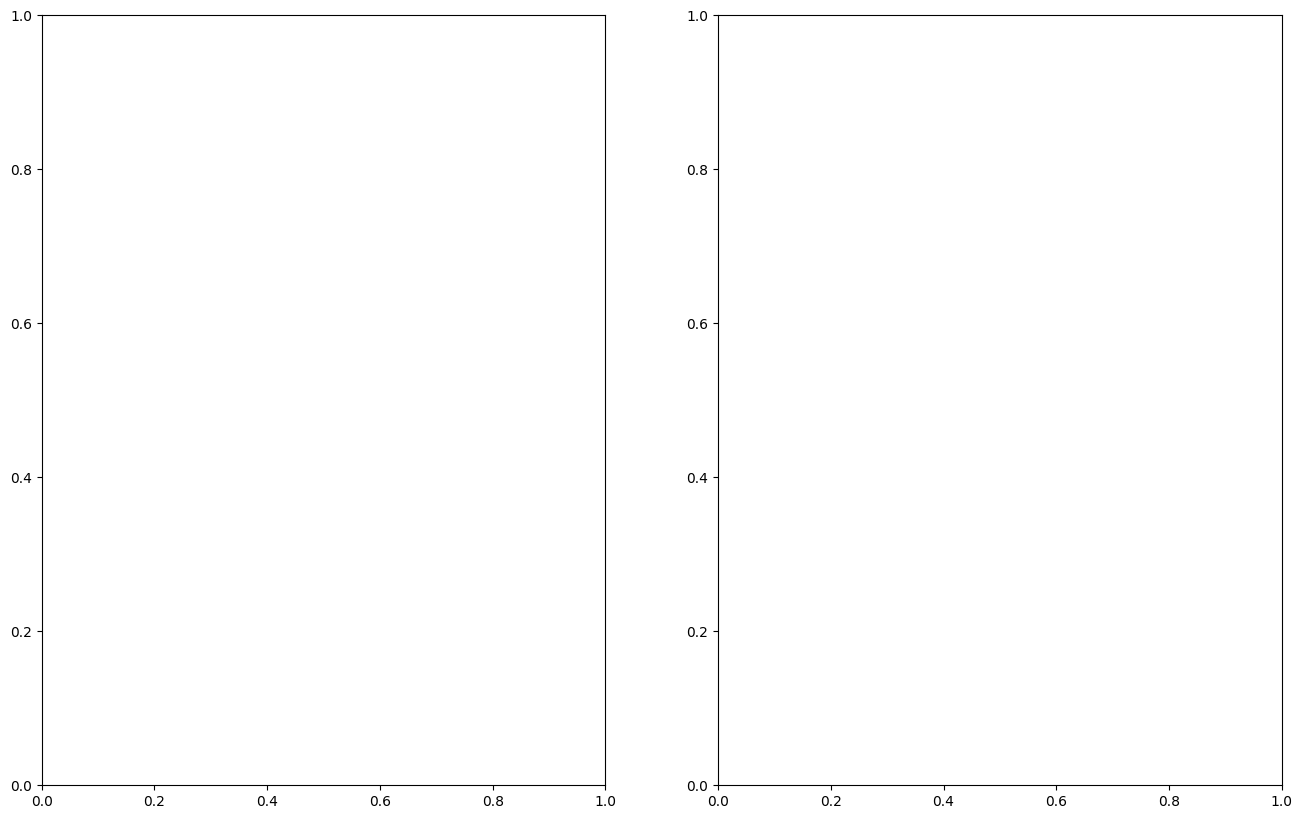

In [45]:
# 1.1 Three different arbitrarly defined and itteratively chosen learning rates
lrs:list = [0.05, 0.01, 0.00314]

# 1.2 Invoke the preprocessed loaders and define the label
train_loader, val_loader, test_loader = pipeline()
model_label:str = 'default_CNN'

# 2. Declaration of utilities (e.g., loader) 
# ...and model components initialization (such as optimizer and loss criteiron), 
# ...plus train val list-containers;
for index,lr in enumerate(lrs):
    model_CNN = DefaultCNN(depth_no_cn_lay=4, width_no_kern=[1, 36, 6, 36, 1], sum=False)
    optim = SGD(model_CNN.parameters(), lr=lr)
    loss = MSELoss()
    container_Train_Loss, container_Val_Loss  = [],[]
    model_label_specific = model_label+f"_lr_{lr}"

    # 3. Training loop
    for epoch in range(args.epochs):
            # 3.1 Initializing training mode and variable where performance over training set is being stored;
            train_loss:float = 0.0
            val_loss:float = 0.0
            model_CNN.train()
            for cl, ns, label in train_loader:
                optim.zero_grad() # 3.2 Reset the gradient cache memory and feed model(z) with samples
                _output_tr = model_CNN(ns) 
                # # Debug Statement - 2
                # axis[0].imshow(ns[0][0])
                # axis[1].imshow(_output[0][0].detach())
                _loss_tr = loss(_output_tr, cl) # 3.3 Determine the loss
                train_loss +=_loss_tr.item()
                # 3.4 Backpropagation pass and gradient-step
                _loss_tr.backward()
                optim.step()
            
            container_Train_Loss.append(train_loss/len(train_loader))
            
            # 4. Validation Loop
            with torch.no_grad():
                # 4.1 Initializing validation mode
                model_CNN.eval()
                for cl, ns, label in val_loader:
                     _output_val = model_CNN(ns) # Same as 3.2
                     _loss_val = loss(_output_val, cl) # Same as 3.3
                     val_loss+=_loss_val.item()

            container_Val_Loss.append(val_loss/len(val_loader))
            # 5. Report out the results 
            print(f"Epoch {epoch}: Training Loss: {train_loss/len(train_loader)}| Validation Loss: {val_loss/len(val_loader)}") 

            # 6. Save the model and yielded history per epoch
            save_hist(model=model_CNN, model_label=model_label_specific)

    save_hist(hist=(container_Train_Loss,container_Val_Loss),model_label=model_label_specific)




In [54]:
# 1.2 Invoke the preprocessed loaders and define the label
train_loader, val_loader, test_loader = pipeline(FCN=True)
model_label:str = 'super_FCN_denoiser'

# 2. Declaration of utilities (e.g., loader) 
# ...and model components initialization (such as optimizer and loss criteiron), 
# ...plus train val list-containers;
denoiser = DefaultFCN(
        activation=['LeakyReLU', 'Tanh'],
        width=[32**2, 24**2, 22**2, 20**2, 22**2, 24**2, 32**2],
        depth=6
    )

optim = SGD(denoiser.parameters(), lr=0.01)
loss = MSELoss()
container_Train_Loss, container_Val_Loss  =[],[]
model_label_specific = model_label

# 3. Training loop
for epoch in range(args.epochs):
        # 3.1 Initializing training mode and variable where performance over training set is being stored;
        train_loss:float = 0.0
        val_loss:float = 0.0
        denoiser.train()
        for cl, ns, label in train_loader:
            optim.zero_grad() # 3.2 Reset the gradient cache memory and feed model(z) with samples
            _output_tr = denoiser(ns) 
            # # Debug Statement - 2
            # axis[0].imshow(ns[0][0])
            # axis[1].imshow(_output[0][0].detach())
            _loss_tr = loss(_output_tr, cl) # 3.3 Determine the loss
            train_loss +=_loss_tr.item()
            # 3.4 Backpropagation pass and gradient-step
            _loss_tr.backward()
            optim.step()
        
        container_Train_Loss.append(train_loss/len(train_loader))
        
        # 4. Validation Loop
        with torch.no_grad():
            # 4.1 Initializing validation mode
            denoiser.eval()
            for cl, ns, label in val_loader:
                    _output_val = denoiser(ns) # Same as 3.2
                    _loss_val = loss(_output_val, cl) # Same as 3.3
                    val_loss+=_loss_val.item()

        container_Val_Loss.append(val_loss/len(val_loader))
        # 5. Report out the results 
        print(f"Epoch {epoch}: Training Loss: {train_loss/len(train_loader)}| Validation Loss: {val_loss/len(val_loader)}") 

        # 6. Save the model and yielded history per epoch
        save_hist(model=denoiser, model_label=model_label_specific)

save_hist(hist=(container_Train_Loss,container_Val_Loss),model_label=model_label_specific)

Epoch 0: Training Loss: 0.8626247738175989| Validation Loss: 0.83868164621341
Epoch 1: Training Loss: 0.48906970748206235| Validation Loss: 0.22842810791768844
Epoch 2: Training Loss: 0.22509198763486368| Validation Loss: 0.22473715767738925
Epoch 3: Training Loss: 0.2232514655841586| Validation Loss: 0.22312694161560884
Epoch 4: Training Loss: 0.22164776646877493| Validation Loss: 0.222036990865021
Epoch 5: Training Loss: 0.2209087898740378| Validation Loss: 0.22140991194233015
Epoch 6: Training Loss: 0.22023841106068448| Validation Loss: 0.22080600593879723
Epoch 7: Training Loss: 0.21965416412219366| Validation Loss: 0.22018398790602473
Epoch 8: Training Loss: 0.21901344749933618| Validation Loss: 0.2195522805118257
Epoch 9: Training Loss: 0.2184641593900483| Validation Loss: 0.2191208344735917
Epoch 10: Training Loss: 0.2179263548168075| Validation Loss: 0.21854794357612634
Epoch 11: Training Loss: 0.21742639837362576| Validation Loss: 0.2182685207978935
Epoch 12: Training Loss: 0.

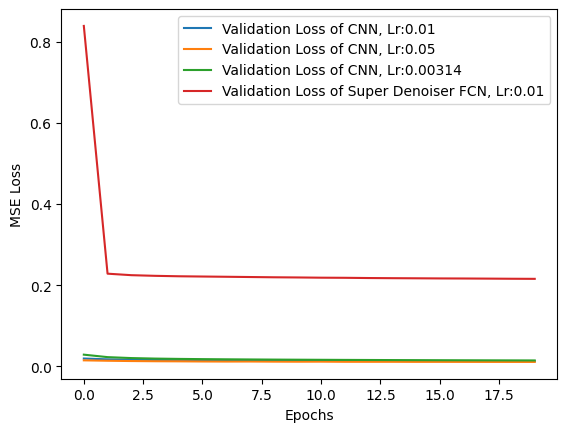

In [10]:
visualization(model_label="CNN, Lr:0.01", path=r'default_CNN_lr_0.01\default_CNN_lr_0.01_accuracy_container\history.csv')
visualization(model_label="CNN, Lr:0.05", path=r'default_CNN_lr_0.05\default_CNN_lr_0.05_accuracy_container\history.csv')
visualization(model_label="CNN, Lr:0.00314", path=r'default_CNN_lr_0.00314\default_CNN_lr_0.00314_accuracy_container\history.csv')
visualization(model_label="Super Denoiser FCN, Lr:0.01", path=r'super_FCN_denoiser\super_FCN_denoiser_accuracy_container\history.csv')

### 2.1.g)

Printing summary...  Sequential(
  (0): Conv2d(1, 36, kernel_size=(3, 3), stride=(1, 1), padding=same)
  (1): ReLU()
  (2): Conv2d(36, 6, kernel_size=(3, 3), stride=(1, 1), padding=same)
  (3): ReLU()
  (4): Conv2d(6, 36, kernel_size=(3, 3), stride=(1, 1), padding=same)
  (5): ReLU()
  (6): Conv2d(36, 1, kernel_size=(3, 3), stride=(1, 1), padding=same)
  (7): Tanh()
)


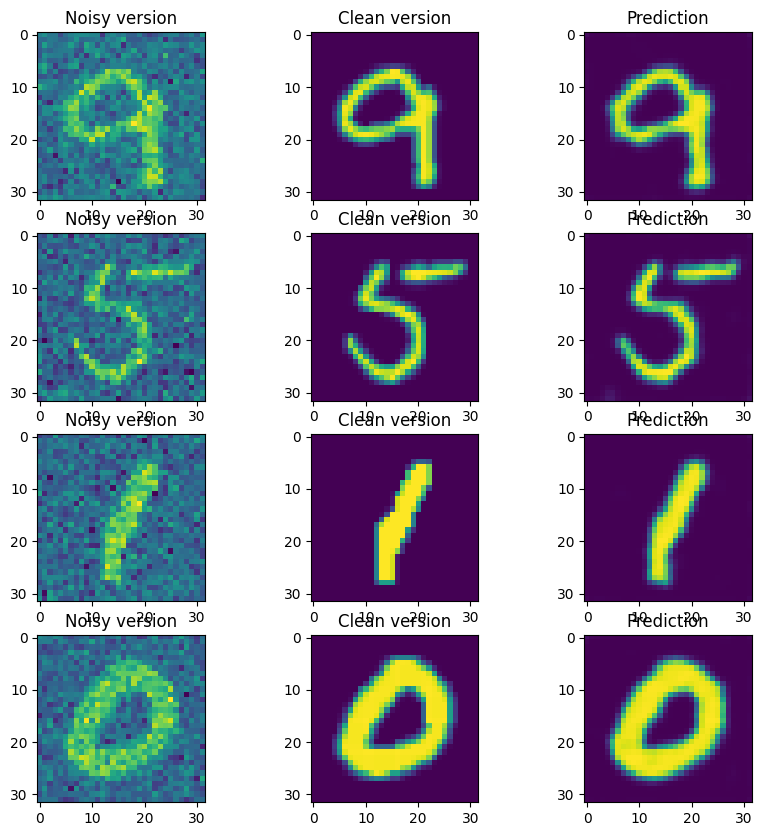

In [ ]:
model_CNN = DefaultCNN(depth_no_cn_lay=4, width_no_kern=[1, 36, 6, 36, 1], sum=True)
weights_path = r'default_CNN_lr_0.05\default_CNN_lr_0.05\default_CNN_lr_0.05model_weights_epoch19.pth'
weights = torch.load(weights_path, weights_only=True)
model_CNN.load_state_dict(weights)

_, _, val_loader = pipeline()
_, (cl, ns, label) = next(enumerate(val_loader))

with torch.no_grad():
    model_CNN.eval()
    output = model_CNN(ns)


fig, axis = PLT.subplots(4, 3, figsize=(10,10))
for index, sample in enumerate(output[:4]):
    axis[index,2].imshow(sample[0])
    axis[index,2].set_title("Prediction")
    axis[index,0].imshow(ns[index][0])
    axis[index,0].set_title("Noisy version")
    axis[index,1].imshow(cl[index][0])
    axis[index,1].set_title("Clean version")
    

### 2.1.h)

Comparing the inputs (e.g., noisy variants of the so-called "sub images") to what the network was able to put back in place (e.g., the reconstructions), it becomes evident that the symmetry is being preserved, as cutting off/discarding pixels will consequently make the digit's corpus move along the diagonal axis. This sort of transformation is nothing more than an aggregate translation (on vertical and horizontal axes) that the convolutional neural network is accustomed to, as this sort of structure is encoded internally into the convolutional operation which involves kernels sliding horizontally over the image. The differences are linked to the network's attribute to vary its output depending on the transformation applied to its input. If we were to assume the translation to be a transformation denoted with `T`, the network represented by symbol `f`, then we should have had the following equation hold true (1) to make the previous statement sound:
$$f(T(x)) = T(f(x))$$

torch.Size([28, 28]) torch.Size([28, 28])


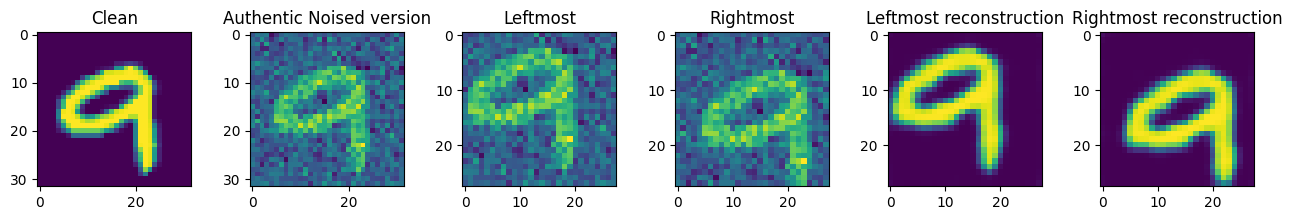

In [37]:
# 1.  Pick an image from the test set and create two 28x28 sub-images from it;
_, _, test_loader = pipeline() # ! Extraneous definition !
sample_batch = next(enumerate(test_loader))
index, (cl, ns, label) = sample
random_img = rdm.randint(0, 63)
sample_noisy_img, sample_cl_img = ns[random_img][0], cl[random_img][0]

# 2.1 *one where the top and leftmost 4 pixels are cut off, 
leftmost_Subimage = sample_noisy_img[4:32,4:32]
# 2.1 *and one where the bottom and rightmost 4 pixels are cut off. 
rightmost_Subimage = sample_noisy_img[0:28,0:28]

# 3. Now run your model on both sub-images. 
model_CNN = DefaultCNN(depth_no_cn_lay=4, width_no_kern=[1, 36, 6, 36, 1], sum=False)
weights_path = r'default_CNN_lr_0.05\default_CNN_lr_0.05\default_CNN_lr_0.05model_weights_epoch19.pth'
weights = torch.load(weights_path, weights_only=True)
model_CNN.load_state_dict(weights)

with torch.no_grad():
    model_CNN.eval()
    leftmost_Output, rightmost_Output = model_CNN(leftmost_Subimage.unsqueeze(0)), model_CNN(rightmost_Subimage.unsqueeze(0))

# 4. Visualization
fig, axis = PLT.subplots(1, 6, figsize=(16,2))

axis[0].imshow(sample_cl_img)
axis[0].set_title('Clean')
axis[1].imshow(sample_noisy_img)
axis[1].set_title('Authentic Noised version')
axis[2].imshow(leftmost_Subimage)
axis[2].set_title('Leftmost')
axis[3].imshow(rightmost_Subimage)
axis[3].set_title('Rightmost')
axis[4].imshow(leftmost_Output[0])
axis[4].set_title("Leftmost reconstruction")
axis[5].imshow(rightmost_Output[0])
axis[5].set_title("Rightmost reconstruction")

print(leftmost_Subimage.shape, rightmost_Subimage.shape)

# Utils (helpers or static methods)

In [7]:
@staticmethod
def visualization(model_label:list,hist:tuple|list=None, path:str|list=None):
    """
    model_label (i.e., the collection of learning rates equipped throughout different trials)
    """

    if path != None:
        # Branch displaying only one validation loss
        if isinstance(path, str):
            data = pd.read_csv(path)
            PLT.plot(data['test_loss'], label=f'Validation Loss of {model_label}')
            PLT.xlabel("Epochs")
            PLT.ylabel("MSE Loss")
        else:
            pass
        

    elif hist != None:
        # 2.1 Assume hist holds train-val pairs respecting the model of a list of tuples,
        # ...for all of which spots need to be created in subplots
        spots = len(hist)

        for spot in range(spots):
            PLT.plot(hist[spot+1], label=f'Test {"Learning rate"+model_label[spot+1]}',color='yellow')
            PLT.xlabel("Epochs")
            PLT.ylabel("MSE Loss")

        PLT.show()
        # rec, col = 2
        train, test 

    else:
        pass

    PLT.legend()
    PLT.grid()

In [6]:
@staticmethod
def save_hist(model_label:str, model:torch=None, hist:list=None):

    # 1. Create and check if directories wherein history is stored exist;
    # 1.1 For weights amd containers that hold MSE-loss scores:
    if model_label != None and (f'{model_label}' in os.listdir()) == False:
        os.makedirs(f'{model_label}')
        if (model_label in os.listdir(f'{model_label}')) == False:
            os.makedirs(f'{model_label}\{model_label}')
            os.makedirs(f'{model_label}\{model_label}_accuracy_container')

    if model != None:
        # 2. Saving history of weights;
        # 2.1 Ensures the weights are saved one epoch at a time:
        torch.save(model.state_dict(), f'{model_label}\{model_label}\{model_label}model_weights_epoch{epoch}.pth')

    if hist != None: # Otherwise skip
        # 3. Ensures both containers are being saved under `high-capacity_accuracy_container\history.csv`
        # 3.1 Convert the lists to a pandas dataframe for easier saving 
        raw_history_frame = pd.DataFrame({
            "train_loss": hist[0], 
            "test_loss": hist[1]
        })

        # 3. Save the dataframe as a .csv file
        raw_history_frame.to_csv(f"{model_label}\{model_label}_accuracy_container\history.csv")
        

<string>:9: SyntaxWarning: invalid escape sequence '\{'
<string>:10: SyntaxWarning: invalid escape sequence '\{'
<string>:15: SyntaxWarning: invalid escape sequence '\{'
<string>:15: SyntaxWarning: invalid escape sequence '\{'
<string>:26: SyntaxWarning: invalid escape sequence '\{'
<>:9: SyntaxWarning: invalid escape sequence '\{'
<>:10: SyntaxWarning: invalid escape sequence '\{'
<>:15: SyntaxWarning: invalid escape sequence '\{'
<>:15: SyntaxWarning: invalid escape sequence '\{'
<>:26: SyntaxWarning: invalid escape sequence '\{'
<>:26: SyntaxWarning: invalid escape sequence '\h'
<string>:9: SyntaxWarning: invalid escape sequence '\{'
<string>:10: SyntaxWarning: invalid escape sequence '\{'
<string>:15: SyntaxWarning: invalid escape sequence '\{'
<string>:15: SyntaxWarning: invalid escape sequence '\{'
<string>:26: SyntaxWarning: invalid escape sequence '\{'
<>:9: SyntaxWarning: invalid escape sequence '\{'
<>:10: SyntaxWarning: invalid escape sequence '\{'
<>:15: SyntaxWarning: inva

In [5]:
@staticmethod
def pipeline(data_dir = args.data_dir, batch_size = args.batch_size, FCN=False):

    def __flatten(data:tuple):
        f = nn.Flatten(start_dim=0) # Start flattening, counting from the very first item in the tuple: (clean, noisy, labels)
        flatten_data = [f(item) if isinstance(item, torch.Tensor) else item for item in data[:-1]] # Neglecting the very last  item ~ labels
                                                                                                                # It can be simplified to: flattened_list = [f(item) for item in data[:-1]]
        return tuple(flatten_data) + (data[-1],) # By adding that trailing comma, you explicitly tell Python: "Treat this single item as a tuple of length 1."

    transforms = v2.Compose([
      __flatten  
    ])

    if FCN is False:
        transforms = None

    train_loader, val_loader, test_loader = create_dataloaders(data_dir, batch_size, transform=transforms)
    
    return train_loader, val_loader, test_loader

In [4]:
@staticmethod
def write_and_display_Message(message:str, title:str)-> None:
    ct.windll.user32.MessageBoxW(0, message, title, 1)

    return True

In [3]:
@staticmethod
def get_parser_Arguments():
    parser = argparse.ArgumentParser(description="Experiment controller")
    parser.add_argument("--data_dir", type=str, default=r"/DataSets", help="Path where data should be store")
    parser.add_argument("--batch_size", type=int, default=64, help="Mini-batch size controller")
    parser.add_argument("--epochs", type=int, default=20, help="No. epochs equivalent to how many times the moedl gets to see the entire data set")
    parser.add_argument("--activations", type=list, default=['ReLU','Sigmoid','Tanh'], help="Collections of activations types")
    parser.add_argument("--optimizaions", type=list, default=['SGD','AdamW'], help="Collections of optimizr types")
    parser.add_argument("--losses", type=list, default=['MSELoss','BCE'], help="Collections of loss types")

    return parser.parse_known_args()[0]

args = get_parser_Arguments()
print(args.batch_size)

64


# Tests

Loaders of size train 782, val 157 and test 157 were sucessfully initialized
Printing summary...  =================================================================
Layer (type:depth-idx)                   Param #
Sequential                               --
├─Conv2d: 1-1                            5,308,992
├─ReLU: 1-2                              --
├─Conv2d: 1-3                            1,327,360
├─ReLU: 1-4                              --
├─Conv2d: 1-5                            2,360,320
├─ReLU: 1-6                              --
Total params: 8,996,672
Trainable params: 8,996,672
Non-trainable params: 0
================================================================= [1024, 576, 256, 1024]
Printing summary...  =================================================================
Layer (type:depth-idx)                   Param #
Sequential                               --
├─Linear: 1-1                            590,400
├─ReLU: 1-2                              --
├─Linear: 1-3       

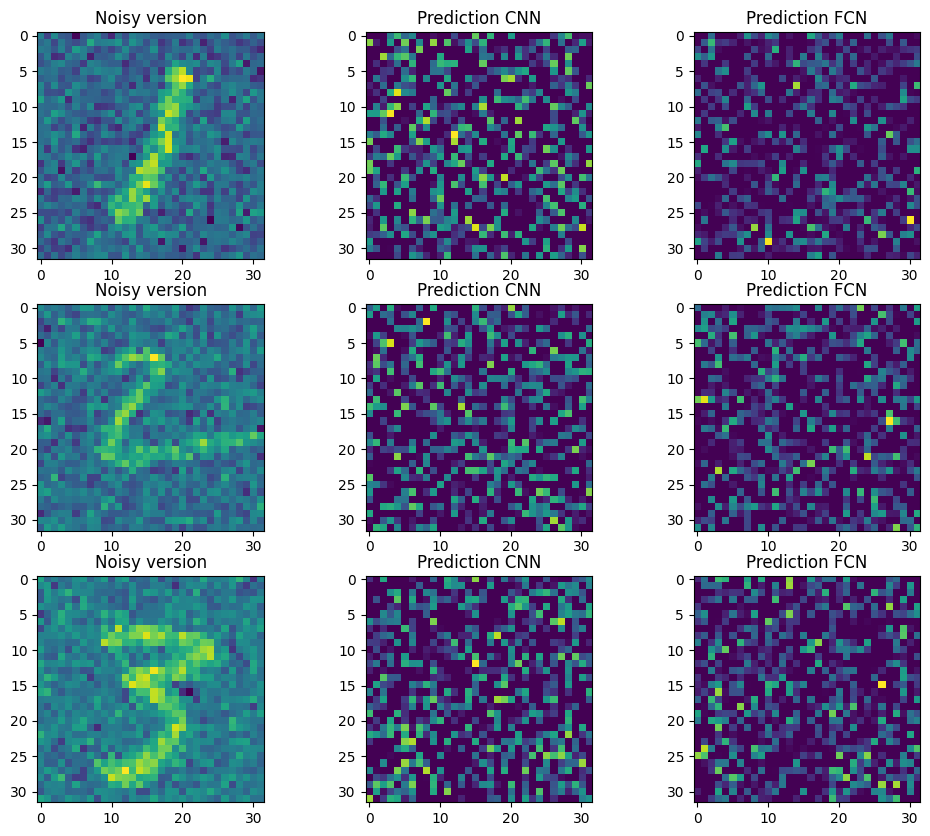

In [10]:
# Sanity Check
args = get_parser_Arguments()
train_loader, val_loader, test_loader = create_dataloaders(args.data_dir, args.batch_size)
print("Loaders of size train {}, val {} and test {} were sucessfully initialized".format(train_loader.__len__(), val_loader.__len__(), test_loader.__len__()))


fig, axis = PLT.subplots(3,3, figsize=(12,10))
for predictions in range(3):
    sample = next(enumerate(test_loader))
    _, (cl, noisy, label) = sample

    model_CNN = DefaultCNN(depth_no_cn_lay=3, width_no_kern=[32**2, 24**2, 16**2, 32**2], sum=True)
    with torch.no_grad():
        model_CNN.eval()
        output_CNN = model_CNN.forward(noisy[0].reshape(-1,1,32**2).permute(2,0,1))

    model_FCN = DefaultFCN(depth=3, width=[32**2, 24**2, 16**2, 32**2], sum=True)
    with torch.no_grad():
        model_FCN.eval()
        output_FCN = model_FCN.forward(noisy[0].reshape(-1,32**2))

    axis[predictions,0].imshow(noisy[0].reshape(32,32))
    axis[predictions,1].imshow(output_CNN.squeeze().reshape(32,32))
    axis[predictions,2].imshow(output_FCN.reshape(32,32))
    axis[predictions,0].set_title(f"Noisy version")
    axis[predictions,1].set_title(f"Prediction CNN")
    axis[predictions,2].set_title(f"Prediction FCN")

print(f"Reshaping...{noisy[0].reshape(-1,1,32**2).permute(2,0,1).shape}")